# Étape 2 — Nettoyage des données Yélé, pas à pas

Ce notebook déroule **cellule par cellule** ce que fait `prepare_data.py` :

1. Chargement de l'export Compass (`yele_speedtest.speedtest_results.json`)
2. Conversion des types (textes → nombres, `$date` → datetime)
3. Récupération des anciens formats (opérateur, city/country)
4. Exclusion des mesures inexploitables
5. Création des variables temporelles (*features*)
6. Normalisation des libellés (doublons ONATEL, pays → ISO)
7. Sauvegarde de `dataset_clean.csv`

> Exécute chaque cellule avec **Maj+Entrée** et observe le résultat avant de passer à la suivante.

## 1. Chargement des données brutes

In [1]:
import pandas as pd
from prepare_data import load_raw, salvage_legacy_fields, normalize_labels, NUMERIC, PII_COLUMNS

df = load_raw()
print(f'{len(df)} mesures brutes, {len(df.columns)} colonnes')
df.head(3)

[chargement] 146 mesures depuis yele_speedtest.speedtest_results.json
146 mesures brutes, 32 colonnes


,_id,uuid,timestamp,ip_address,isp_info,dl,ul,ping,jitter,extra_raw,...,country,streaming_startup_ms,streaming_rebuffer_count,streaming_rebuffer_ratio,streaming_max_resolution,streaming_score,browsing_avg_load_ms,browsing_success_rate,browsing_pages_tested,browsing_score
0,6a2767163e13a1215abcc6bc,01KTMYNC0CG6CEBCKFAE32RWBR,2026-06-09T01:06:30.540Z,,"102.180.101.179 - Orange Burkina Faso, BF (40 mi)",50.21,7.45,316.65,26.87,SM-S9010 - 4G,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6a2767353e13a1215abcc6bd,01KTMYP9SBWQNCBNWCYXMACK89,2026-06-09T01:07:01.035Z,,"102.180.101.179 - Orange Burkina Faso, BF (40 mi)",59.27,8.77,294.44,27.20,SM-S9010 - 4G,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6a2768083e13a1215abcc6be,01KTMYWRJ8MCGSAM3K640YJFWK,2026-06-09T01:10:32.776Z,,"102.180.101.179 - Orange Burkina Faso, BF (40 mi)",46.97,6.16,612.50,39.45,CHROME - Web Connection,...,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Conversion des types
Dans la base, les débits sont stockés en **texte** (`"50.21"`). Un modèle a besoin de **nombres**.
`errors='coerce'` transforme tout ce qui n'est pas convertible en `NaN` (valeur manquante).

In [9]:
print('AVANT :', df['dl'].dtype, '-> exemple :', repr(df['dl'].iloc[0]))

for col in NUMERIC:
    df[col] = pd.to_numeric(df.get(col), errors='coerce')
for col in ['latitude', 'longitude']:
    df[col] = pd.to_numeric(df.get(col), errors='coerce').fillna(0)
df['timestamp'] = pd.to_datetime(df.get('timestamp'), errors='coerce', utc=True, format='mixed')
df = df.dropna(subset=['timestamp'])

print('APRÈS :', df['dl'].dtype, '-> exemple :', df['dl'].iloc[0])
df[NUMERIC].describe().round(1)

AVANT : float64 -> exemple : np.float64(50.21)
APRÈS : float64 -> exemple : 50.21


,dl,ul,ping,jitter
count,145.0,145.0,145.0,145.0
mean,27.2,9.9,429.3,156.5
std,24.5,17.5,304.7,290.0
min,0.0,0.0,0.0,0.0
25%,7.0,1.9,288.5,28.0
50%,20.0,6.8,349.8,57.0
75%,47.0,9.3,494.6,175.4
max,96.6,143.1,2677.2,2682.4


## 3. Récupération des anciens formats
Les premiers tests n'avaient pas `operator`/`city`/`country` structurés — mais l'information
existe dans `isp_info` ("IP - Orange Burkina Faso, BF (40 mi)") et `location` ("Ouagadougou, Burkina Faso").
On la **récupère** au lieu de jeter ces lignes, en **validant** chaque morceau
(rejet des coordonnées GPS et des fragments tronqués type `"PTT)"`).

In [10]:
vides_avant = (df['operator'] == '').sum()
df = salvage_legacy_fields(df)
vides_apres = (df['operator'] == '').sum()
print(f'Opérateurs vides : {vides_avant} -> {vides_apres}')

[récupération] opérateur retrouvé via isp_info : 6
[récupération] appareil/réseau via extra_raw    : 6/6
[récupération] city/country via location        : 92/107
Opérateurs vides : 27 -> 21


## 4. Exclusion des mesures inexploitables
Un test avec débit 0 ou vide ne peut pas entraîner un modèle de débit.
On borne aussi aux valeurs physiquement plausibles (< 2000 Mb/s, ping < 5000 ms).

In [11]:
avant = len(df)
df = df.dropna(subset=['dl'])
df = df[(df['dl'] > 0) & (df['dl'] < 2000)]
df = df[(df['ping'].isna()) | ((df['ping'] >= 0) & (df['ping'] < 5000))]
print(f'{avant - len(df)} mesures écartées, {len(df)} conservées')

9 mesures écartées, 137 conservées


## 5. Variables temporelles (*feature engineering*)
Le modèle ne comprend pas une date brute. On en extrait ce qui influence le réseau :
l'**heure** (heures chargées 18h-23h), le **jour de semaine**, le **week-end**.

In [12]:
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

for col in ['operator', 'network_type', 'sim_operator', 'cellular_tech',
            'device_model', 'location', 'city', 'country']:
    if col in df.columns:
        df[col] = df[col].fillna('Inconnu').replace('', 'Inconnu')

df['is_wifi'] = (df['network_type'].astype(str).str.upper()
                 .str.contains('WIFI', na=False)).astype(int)

df[['timestamp', 'hour', 'dayofweek', 'is_weekend', 'is_wifi']].head(8)

,timestamp,hour,dayofweek,is_weekend,is_wifi
0,2026-06-09 01:06:30.540000+00:00,1,1,0,0
1,2026-06-09 01:07:01.035000+00:00,1,1,0,0
2,2026-06-09 01:10:32.776000+00:00,1,1,0,0
3,2026-06-09 01:11:34.613000+00:00,1,1,0,0
4,2026-06-09 01:30:54.833000+00:00,1,1,0,0
5,2026-06-09 01:31:53.212000+00:00,1,1,0,0
6,2026-06-09 01:33:56.290000+00:00,1,1,0,0
7,2026-06-09 01:38:59.754000+00:00,1,1,0,0


## 6. Normalisation des libellés (doublons)
"ONATEL (..., PTT)" et "ONATEL (..." sont le **même opérateur** écrit de deux façons.
Sans fusion, les statistiques et l'IA les traitent comme deux catégories.

In [13]:
df = normalize_labels(df)
df['operator'].value_counts()

[normalisation] opérateurs : 8 -> 7 libellés distincts


operator
Orange Burkina Faso      47
ANPTIC                   42
Inconnu                  20
ONATEL / Telmob          17
ARCEP Burkina             8
GVA Cote d'Ivoire SAS     2
Green Mini host BV        1
Name: count, dtype: int64

## 7. Suppression des champs personnels et sauvegarde
Les champs PII (`ip_address`, `isp_info`, `user_agent`...) ne doivent **jamais**
entrer dans un dataset d'apprentissage.

In [14]:
df = df.drop(columns=[c for c in PII_COLUMNS if c in df.columns]).reset_index(drop=True)
df.to_csv('dataset_clean.csv', index=False)
print(f'{len(df)} lignes -> dataset_clean.csv')
print('Colonnes finales :', list(df.columns))

137 lignes -> dataset_clean.csv
Colonnes finales : ['uuid', 'timestamp', 'dl', 'ul', 'ping', 'jitter', 'operator', 'network_type', 'device_model', 'location', 'latitude', 'longitude', 'qoe_rating', 'qoe_sat', 'city', 'country', 'streaming_startup_ms', 'streaming_rebuffer_count', 'streaming_rebuffer_ratio', 'streaming_max_resolution', 'streaming_score', 'browsing_avg_load_ms', 'browsing_success_rate', 'browsing_pages_tested', 'browsing_score', 'hour', 'dayofweek', 'is_weekend', 'is_wifi']


## Bilan visuel rapide

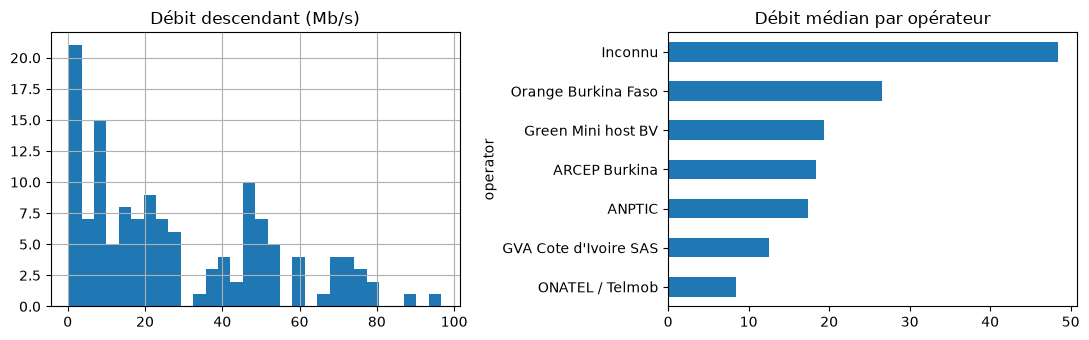

In [15]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
df['dl'].hist(bins=30, ax=axes[0]); axes[0].set_title('Débit descendant (Mb/s)')
df.groupby('operator')['dl'].median().sort_values().plot.barh(ax=axes[1])
axes[1].set_title('Débit médian par opérateur')
plt.tight_layout(); plt.show()